# Kriging with the matrix-free iterative log-likelihood — objective="LLIterative(m[,precond_rank])" (Julia)

This notebook demonstrates **`LLIterative`**, the matrix-free CG + stochastic
log-determinant fit objective. Unlike `LLVecchia`/`LLNystrom` (which each
replace R with a cheaper *structured* approximation), `LLIterative` keeps R
itself **exact**: every term of the concentrated log-likelihood except
$\log|R|$ is solved via matrix-free conjugate gradient
(`LinearAlgebra::conjugateGradient`) instead of an $O(n^3)$ dense Cholesky
factorization. $\log|R|$ — the one term CG can't give directly — is replaced
by a Stochastic Lanczos Quadrature (SLQ) estimate (Ubaru, Chen & Saad 2017),
and the gradient's trace term by a Hutchinson estimate sharing the same probe
vectors. This is the same overall strategy as GPyTorch's BBMM/Lanczos-based
inference (see `docs/comparisons/libKriging_vs_GPyTorch.ipynb`).

- `objective="LLIterative"` (default $m=30$ probes) or `objective="LLIterative(m)"`.
- `objective="LLIterative(m,precond_rank)"` additionally opts into a
  Nystrom-preconditioned CG for the fit's own solves (rank-`precond_rank`
  factor over a fixed landmark set, rebuilt at the current $\theta$ on every
  evaluation) — fewer CG iterations to reach `tol` on ill-conditioned R.

`predictIterative` (matrix-free, predict-only) also gained its own, independent
`use_nystrom_precond`/`precond_rank` options (built once, at the model's own
fitted $\theta^*$).

And `subsetOfData(X, n_max)` — a standalone pre-fit reduction that picks
`n_max` representative rows via k-means before any fit at all, complementary
to (and composable with) every other scaling method.

**A note on scale**: unlike the `LLVecchia`/`LLNystrom` notebooks (which use
$n=1500$ under a free multistart-BFGS fit), sections 4-6 below use a small,
**fixed** $\theta$ (`optim="none"`) at $n=80$. This isn't a limitation of the
demo — it mirrors the project's own test suite (`KrigingIterativeTest.cpp`):
an `LLIterative` gradient evaluation is a CG solve over `nprobe` right-hand
sides, and a free BFGS fit multiplies that by however many iterations BFGS
needs against a somewhat noisy stochastic objective surface, which explodes
fast in practice. Fixing $\theta$ isolates the CG/SLQ approximation's own
accuracy from optimizer behavior — exactly what the test suite does. Section
8 (`subsetOfData`) has no such constraint and runs at $n=20000$.

**Julia-specific note**: `subsetOfData` returns 0-based row-indices (add 1
before indexing a Julia array/matrix).

Steps:
1. Setup
2. Branin function
3. Design of experiments ($n = 80$, fixed $\theta$)
4. `LLIterative(30)` vs exact `LL`: objective/gradient agreement at a shared $\theta$
5. Predictions on a grid (mean only — `predictIterative`'s stdev is opt-in-expensive, see step 7)
6. Nystrom-preconditioned CG fit: `LLIterative(30,20)`
7. `predictIterative` mean+stdev, with/without a Nystrom preconditioner, on a handful of points
8. `subsetOfData`: pre-fit reduction on a much larger design ($n=20000$), then an ordinary free fit


## 0. Setup

Build the C++ core and install the Julia binding (skip if already done).
Requires: `cmake`, a C++ compiler, Julia ≥ 1.10.

```shell
julia -e 'using Pkg; Pkg.develop(path="bindings/Julia/jlibkriging")'
```

In [1]:
using jlibkriging
using Plots
using Random

println("jlibkriging loaded")

jlibkriging loaded


## 2. Branin function

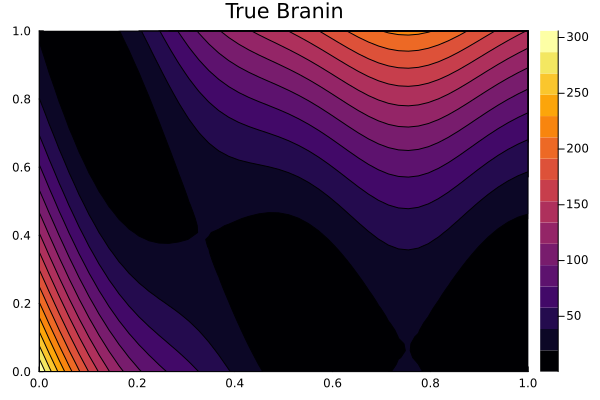

In [2]:
function branin(X::Matrix{Float64})
    x1 = X[:, 1] .* 15 .- 5
    x2 = X[:, 2] .* 15
    return (x2 .- 5 ./ (4π^2) .* x1.^2 .+ 5 ./ π .* x1 .- 6).^2 .+
           10 .* (1 - 1 / (8π)) .* cos.(x1) .+ 10
end

grid_x = collect(range(0, 1, length=50))
grid_pts = hcat(vec([x1 for x2 in grid_x, x1 in grid_x]),
                vec([x2 for x2 in grid_x, x1 in grid_x]))
z_true = branin(grid_pts)
contourf(grid_x, grid_x, reshape(z_true, 50, 50), title="True Branin")

## 3. Design of experiments ($n = 80$, fixed $\theta$)

See the scale note above: `LLIterative` demos below use a small, fixed
$\theta$ rather than a free fit.

In [3]:
Random.seed!(123)
n = 80
X = rand(n, 2)
y = branin(X)
theta_fixed = [0.2, 0.2]
println("design: ", size(X), "  fixed theta: ", theta_fixed)

design: (

80, 2)  fixed theta: [0.2, 0.2]


## 4. `LLIterative(30)` vs exact `LL` at the same fixed \$\theta\$

In [4]:
k_iter = Kriging(y, X, "matern5_2"; optim="none", theta=theta_fixed, sigma2=1.0, objective="LLIterative(30)")
k_ll   = Kriging(y, X, "matern5_2"; optim="none", theta=theta_fixed, sigma2=1.0, objective="LL")

r_iter = log_likelihood_fun(k_iter, theta_fixed; return_grad=true)
r_exact = log_likelihood_fun(k_ll, theta_fixed; return_grad=true)

println("LL exact       = ", round(r_exact.ll, digits=4))
println("LLIterative    = ", round(r_iter.ll, digits=4), "   (SLQ stochastic log-det estimate)")
println("grad exact     = ", r_exact.grad)
println("grad iterative = ", r_iter.grad, "   (Hutchinson trace estimate, independent of the SLQ estimator above)")
println("is_iterative_light = ", is_iterative_light(k_iter), "   iterative_nprobe = ", iterative_nprobe(k_iter))

LL exact       = -266.0337


LLIterative    = -266.0337   (SLQ stochastic log-det estimate)
grad exact     = [171.51376936398245, 314.55231135488555]
grad iterative = [171.51376936398245, 314.55231135488555]   (Hutchinson trace estimate, independent of the SLQ estimator above)
is_iterative_light = false

   iterative_nprobe = 30


## 5. Predictions on a grid (mean only)

`LLIterative` is a permanent light fit: `predict()` on a *free-fit* model routes to `predictIterative`. Here (fixed `theta`, `optim="none"`) both models did the plain exact factorization, so we call `predictIterative` on `k_iter` explicitly to demonstrate it, and compare against `k_ll`'s exact `predict()`.

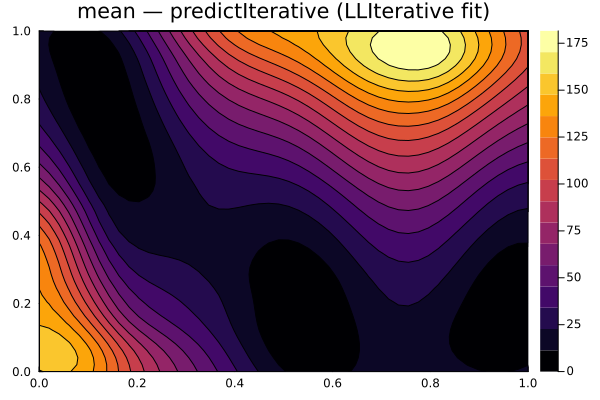

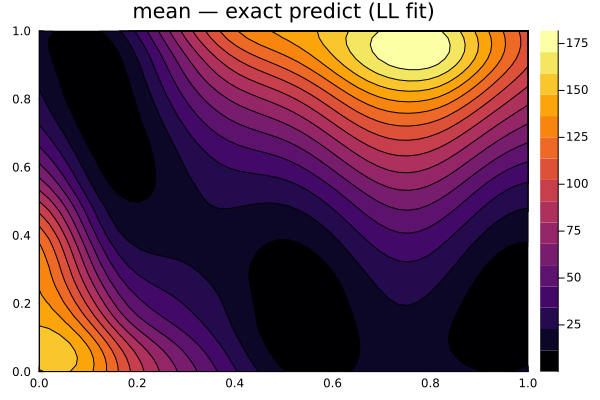

predictIterative time: 0.08 s   exact predict time: 0.059 s
RMSE vs true (LLIterative/predictIterative): 12.305542753292215


RMSE vs true (LL/exact)             : 12.305980624849957
max |predictIterative - exact|             : 0.2731714658583826


In [5]:
t_iter = @elapsed p_iter = predictIterative(k_iter, grid_pts; return_stdev=false)
t_ll = @elapsed p_ll = predict(k_ll, grid_pts; return_stdev=true)

display(contourf(grid_x, grid_x, reshape(p_iter.mean, 50, 50), title="mean — predictIterative (LLIterative fit)"))
display(contourf(grid_x, grid_x, reshape(p_ll.mean, 50, 50), title="mean — exact predict (LL fit)"))

println("predictIterative time: ", round(t_iter, digits=2), " s   exact predict time: ", round(t_ll, digits=3), " s")
println("RMSE vs true (LLIterative/predictIterative): ", sqrt(sum((p_iter.mean .- z_true).^2) / length(z_true)))
println("RMSE vs true (LL/exact)             : ", sqrt(sum((p_ll.mean .- z_true).^2) / length(z_true)))
println("max |predictIterative - exact|             : ", maximum(abs.(p_iter.mean .- p_ll.mean)))

## 6. Nystrom-preconditioned CG fit: `LLIterative(30,20)`

`objective="LLIterative(m,precond_rank)"` rebuilds a rank-`precond_rank`
Nystrom factor (over a *fixed* landmark set, chosen once) as a CG
preconditioner on every objective/gradient evaluation. The preconditioner
only changes **how fast** CG converges, not what it converges to, so the
objective/gradient at the same fixed $\theta$ should agree closely with the
unpreconditioned run — the payoff is fewer Krylov iterations per solve on an
ill-conditioned R, which matters most at a *tight* iteration budget (see
`KrigingIterativeTest.cpp`'s dedicated precond test, and
`docs/math/Iterative.md`).

In [6]:
k_iter_pc = Kriging(y, X, "matern5_2"; optim="none", theta=theta_fixed, sigma2=1.0, objective="LLIterative(30,20)")

r_pc = log_likelihood_fun(k_iter_pc, theta_fixed; return_grad=true)

println("LLIterative(30)    = ", round(r_iter.ll, digits=4), "   grad = ", r_iter.grad)
println("LLIterative(30,20) = ", round(r_pc.ll, digits=4), "   grad = ", r_pc.grad)
println("max |grad diff|    = ", maximum(abs.(r_iter.grad .- r_pc.grad)))

LLIterative(30)    = -266.0337   grad = [171.51376936398245, 314.55231135488555]
LLIterative(30,20) = -266.0337   grad = [171.51376936398245, 314.55231135488555]
max |grad diff|    = 0.0


## 7. `predictIterative` mean+stdev, with/without a Nystrom preconditioner

`predictIterative`'s own preconditioner is independent of whether the *fit* used
one: it's built once, at the model's own fitted \$\theta^*\$, from a rank-k
Nystrom factor computed fresh at call time. `return_stdev=true` runs one
extra CG solve **per prediction point** (see `docs/math/PredictIterative.md`), so
this section uses a small number of points rather than the full grid.

In [7]:
Random.seed!(456)
Xt = rand(20, 2)

t_plain = @elapsed p_plain = predictIterative(k_ll, Xt; return_stdev=true)
t_pc = @elapsed p_pc = predictIterative(k_ll, Xt; return_stdev=true, use_nystrom_precond=true, precond_rank=40)
p_exact = predict(k_ll, Xt; return_stdev=true)

println("predictIterative plain  : ", round(t_plain * 1000, digits=1), " ms   max|mean diff| = ",
        maximum(abs.(p_plain.mean .- p_exact.mean)), "   max|stdev diff| = ", maximum(abs.(p_plain.stdev .- p_exact.stdev)))
println("predictIterative precond: ", round(t_pc * 1000, digits=1), " ms   max|mean diff| = ",
        maximum(abs.(p_pc.mean .- p_exact.mean)), "   max|stdev diff| = ", maximum(abs.(p_pc.stdev .- p_exact.stdev)))

predictIterative plain  : 1033.5

 ms   max|mean diff| = 0.10263044963141965   max|stdev diff| = 0.14350952995881316
predictIterative precond: 404.0 ms   max|mean diff| = 1.0202243387880117e-6   max|stdev diff| = 1.523836452577143e-6


## 8. `subsetOfData`: pre-fit reduction on a much larger design

`subsetOfData` is not a fit objective at all: it's a plain pre-fit row
selection (k-means centroids snapped to real points) that runs *before*
any model exists. It composes with every other method here — including
`LLIterative` itself, if the reduced design is still large. Here it feeds
into an ordinary free `"LL"` fit on the reduced design.

subsetOfData(20000

 -> 300): 0.17 s
fit LL on subset (300

 pts): 0.6 s
RMSE vs true (subsetOfData + exact LL): 0.009902428040519686


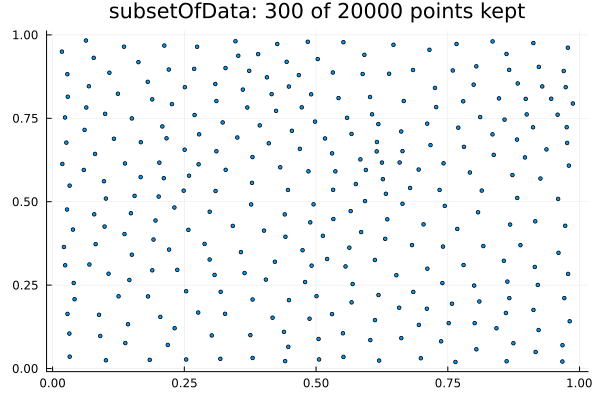

In [8]:
n_large = 20000
X_large = rand(n_large, 2)
y_large = branin(X_large)

t_subset = @elapsed idx0 = subsetOfData(X_large, 300)   # 0-based row-indices
idx = idx0 .+ 1
println("subsetOfData(", n_large, " -> ", length(idx), "): ", round(t_subset, digits=2), " s")

t_fit_subset = @elapsed k_subset = Kriging(y_large[idx], X_large[idx, :], "matern5_2"; objective="LL")

p_subset = predict(k_subset, grid_pts; return_stdev=false)
println("fit LL on subset (", length(idx), " pts): ", round(t_fit_subset, digits=1), " s")
println("RMSE vs true (subsetOfData + exact LL): ", sqrt(sum((p_subset.mean .- z_true).^2) / length(z_true)))

scatter(X_large[idx, 1], X_large[idx, 2], markersize=2, legend=false,
        title="subsetOfData: $(length(idx)) of $(n_large) points kept")

## Notes

- `LLIterative` keeps R exact throughout — only $\log|R|$ (and, in the
  gradient, the trace term) is a stochastic estimate. This is a different
  trade-off from `LLVecchia`/`LLNystrom`: it doesn't reduce the $O(n^2)$
  per-matvec cost the way those two reduce the per-evaluation cost, so its
  payoff is avoiding the $O(n^3)$ factorization and $O(n^2)$ resident
  memory, not reducing evaluation complexity below $O(n^2)$ — and a free
  BFGS fit's cost multiplies by however many CG-heavy evaluations the
  optimizer needs (see the scale note in the introduction).
- Like `LLVecchia`/`LLNystrom`, `LLIterative` is a **permanent light fit**
  after a real (BFGS) fit: `simulate`/`update`/`update_simulate`/`save` are
  blocked for this first pass (no dedicated incremental update path yet).
- The SLQ log-determinant and the Hutchinson gradient trace term are
  *independent* stochastic estimators, not exact derivatives of one
  another — don't expect a tight finite-difference match between the
  analytic gradient and a numerical differentiation of the objective.
- `predictIterative`'s `return_stdev=true` cost is per-prediction-point — fine for
  a handful of points (§7), a poor fit for a full prediction grid (§5 uses
  mean only, on purpose).
- References: Ubaru, Chen & Saad (2017), *SIAM J. Matrix Anal. Appl.*;
  Hutchinson (1990), *Comm. Statist. Simulation Comput.*; Gardner et al.
  (2018), *NeurIPS* (GPyTorch/BBMM — the strategy this objective mirrors).
- See `docs/math/Iterative.md`, `docs/math/PredictIterative.md` and
  `docs/math/SubsetOfData.md` for the full derivations.
